## 1. Importing Required Libraries

In this step, the required Python libraries are imported for data analysis, visualization, model training, and model evaluation.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Loading the Dataset

The dataset is loaded from CSV files. The training data is used to train and evaluate the machine learning models, while the test data is used for final predictions.

In [ ]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
output_df = pd.read_csv("/content/output.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Output Shape:", output_df.shape)

Train Shape: (709, 8)
Test Shape: (315, 8)
Output Shape: (315, 2)


## 3. Data Understanding

In this step, the structure of the dataset is explored by checking the number of rows, columns, feature names, and sample records.

In [ ]:
print("Train Columns:")
print(train_df.columns)

print("\nTrain Data:")
train_df.head()

Train Columns:
Index(['Gender', 'Age', 'openness', 'neuroticism', 'conscientiousness',
       'agreeableness', 'extraversion', 'Personality (Class label)'],
      dtype='object')

Train Data:


,Gender,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion,Personality (Class label)
0,Male,17,7,4,7,3,2,extraverted
1,Male,19,4,5,4,6,6,serious
2,Female,18,7,6,4,5,5,dependable
3,Female,22,5,6,7,4,3,extraverted
4,Female,19,7,4,6,5,4,lively


In [ ]:
print("Output Columns:")
print(output_df.columns)

output_df.head()

Output Columns:
Index(['Person No', 'Predicted Personality'], dtype='object')


,Person No,Predicted Personality
0,1,dependable
1,2,serious
2,3,serious
3,4,serious
4,5,responsible


## 4. Data Cleaning

Missing values are checked and removed to ensure that the dataset is suitable for machine learning model training.

In [ ]:
train_df.isnull().sum()

,0
Gender,0
Age,0
openness,0
neuroticism,0
conscientiousness,0
agreeableness,0
extraversion,0
Personality (Class label),0


In [ ]:
train_df = train_df.dropna()

## 5. Feature Selection

The input features are separated from the target variable.

The target variable is **Personality (Class label)**.

The input features include demographic and personality trait scores.

In [ ]:
target_column = "Personality (Class label)"

X = train_df.drop(target_column, axis=1)
y = train_df[target_column]

X.head()

,Gender,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion
0,Male,17,7,4,7,3,2
1,Male,19,4,5,4,6,6
2,Female,18,7,6,4,5,5
3,Female,22,5,6,7,4,3
4,Female,19,7,4,6,5,4


## 6. Encoding Categorical Variables

Machine learning models require numerical input. Since the Gender column contains text values, it is converted into numerical format using one-hot encoding.

In [ ]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion,Gender_Female,Gender_Male
0,17,7,4,7,3,2,False,True
1,19,4,5,4,6,6,False,True
2,18,7,6,4,5,5,True,False
3,22,5,6,7,4,3,True,False
4,19,7,4,6,5,4,True,False


## 7. Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate model performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (567, 8)
X_test shape: (142, 8)


## 8. Model Training

Three machine learning approaches are used in this project:

1. Logistic Regression
2. Naive Bayes
3. SVD + Logistic Regression

These models are trained and compared to identify the best-performing model.
### 8.1 Logistic Regression

Logistic Regression is used as a baseline classification model for predicting personality categories.


In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.19718309859154928
              precision    recall  f1-score   support

  dependable       0.15      0.13      0.14        31
 extraverted       0.16      0.19      0.17        32
      lively       0.08      0.05      0.06        22
 responsible       0.20      0.18      0.19        22
     serious       0.30      0.37      0.33        35

    accuracy                           0.20       142
   macro avg       0.18      0.18      0.18       142
weighted avg       0.18      0.20      0.19       142



### 8.2 Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It is simple, fast, and effective for classification tasks.

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.176056338028169
              precision    recall  f1-score   support

  dependable       0.18      0.26      0.21        31
 extraverted       0.15      0.09      0.12        32
      lively       0.14      0.14      0.14        22
 responsible       0.21      0.23      0.22        22
     serious       0.18      0.17      0.18        35

    accuracy                           0.18       142
   macro avg       0.17      0.18      0.17       142
weighted avg       0.17      0.18      0.17       142



### 8.3 SVD + Logistic Regression

Singular Value Decomposition (SVD) is used for dimensionality reduction. After reducing the feature dimensions, Logistic Regression is applied for classification.

In [ ]:
svd_lr_model = Pipeline([
    ("svd", TruncatedSVD(n_components=5, random_state=42)),
    ("logistic", LogisticRegression(max_iter=1000))
])

svd_lr_model.fit(X_train, y_train)

svd_pred = svd_lr_model.predict(X_test)

svd_accuracy = accuracy_score(y_test, svd_pred)

print("SVD + Logistic Regression Accuracy:", svd_accuracy)
print(classification_report(y_test, svd_pred))

SVD + Logistic Regression Accuracy: 0.176056338028169
              precision    recall  f1-score   support

  dependable       0.16      0.10      0.12        31
 extraverted       0.19      0.28      0.23        32
      lively       0.11      0.05      0.06        22
 responsible       0.18      0.14      0.15        22
     serious       0.18      0.26      0.21        35

    accuracy                           0.18       142
   macro avg       0.16      0.16      0.16       142
weighted avg       0.17      0.18      0.16       142



## 9. Model Evaluation and Comparison

The models are evaluated using accuracy score and classification report. Their performance is compared to identify the best model.

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVD + Logistic Regression"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svd_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.197183
1,Naive Bayes,0.176056
2,SVD + Logistic Regression,0.176056


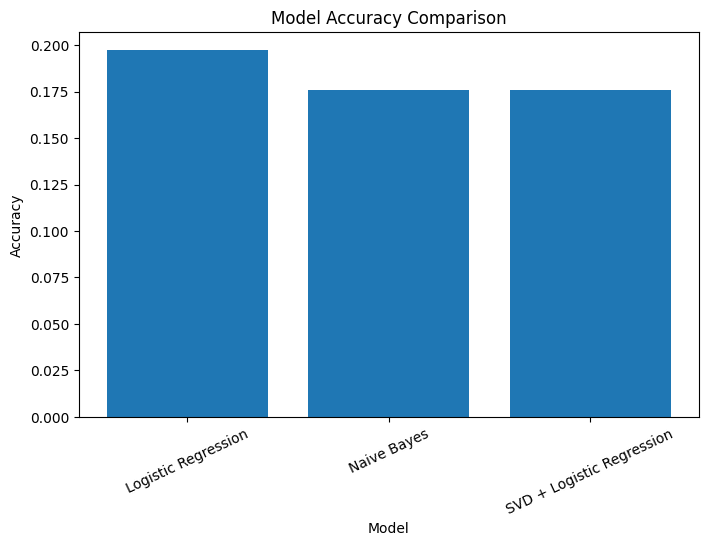

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()

## 10. Confusion Matrix

A confusion matrix is used to visualize how well the model predicted each personality class compared to the actual labels.

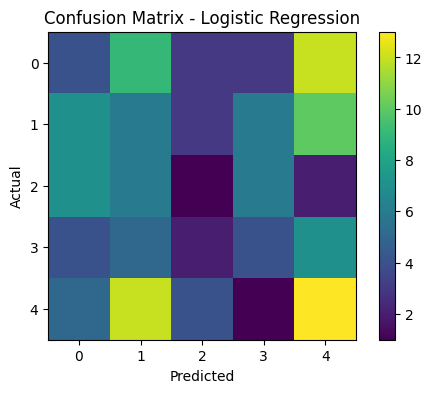

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
test_df.head()

,Gender,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion,Personality (class label)
0,Female,20,7,9,9,5,5,dependable
1,Male,17,5,4,5,2,4,serious
2,Female,25,5,5,7,2,4,serious
3,Female,18,6,2,7,4,7,serious
4,Female,19,2,4,7,1,3,responsible


## 11. Final Prediction on Test Data

The best-performing model is used to predict personality labels for unseen test data.

In [ ]:
test_features = pd.get_dummies(test_df, drop_first=True)

# Match training columns
test_features = test_features.reindex(columns=X.columns, fill_value=0)

final_predictions = lr_model.predict(test_features)

final_predictions[:10]

array(['extraverted', 'responsible', 'serious', 'serious', 'serious',
       'serious', 'serious', 'extraverted', 'serious', 'serious'],
      dtype=object)

In [ ]:
submission = pd.DataFrame({
    "Person No": range(1, len(final_predictions) + 1),
    "Predicted Personality": final_predictions
})

submission.head()

,Person No,Predicted Personality
0,1,extraverted
1,2,responsible
2,3,serious
3,4,serious
4,5,serious


In [ ]:
submission.to_csv("personality_predictions.csv", index=False)

## Final Conclusion

The Personality Prediction System was successfully developed using machine learning techniques.

The dataset contained demographic and personality trait features such as Gender, Age, Openness, Neuroticism, Conscientiousness, Agreeableness, and Extraversion.

Three models were trained and compared:
- Logistic Regression
- Naive Bayes
- SVD + Logistic Regression

The best-performing model was selected based on accuracy score and used to predict personality labels for unseen test data.

This project demonstrates the application of supervised machine learning for classification-based personality prediction.

## Model Performance Observation

The accuracy scores of the models are relatively low. This may be due to the limited size of the dataset and overlapping personality classes.

Personality prediction is a complex classification task, and simple questionnaire-based features may not be enough to achieve high accuracy.

However, the project successfully demonstrates the complete machine learning workflow, including preprocessing, model training, evaluation, comparison, and prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.2605633802816901
              precision    recall  f1-score   support

  dependable       0.23      0.16      0.19        31
 extraverted       0.34      0.38      0.36        32
      lively       0.28      0.32      0.30        22
 responsible       0.19      0.23      0.21        22
     serious       0.24      0.23      0.23        35

    accuracy                           0.26       142
   macro avg       0.26      0.26      0.26       142
weighted avg       0.26      0.26      0.26       142



In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVD + Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svd_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.197183
1,Naive Bayes,0.176056
2,SVD + Logistic Regression,0.176056
3,Random Forest,0.260563


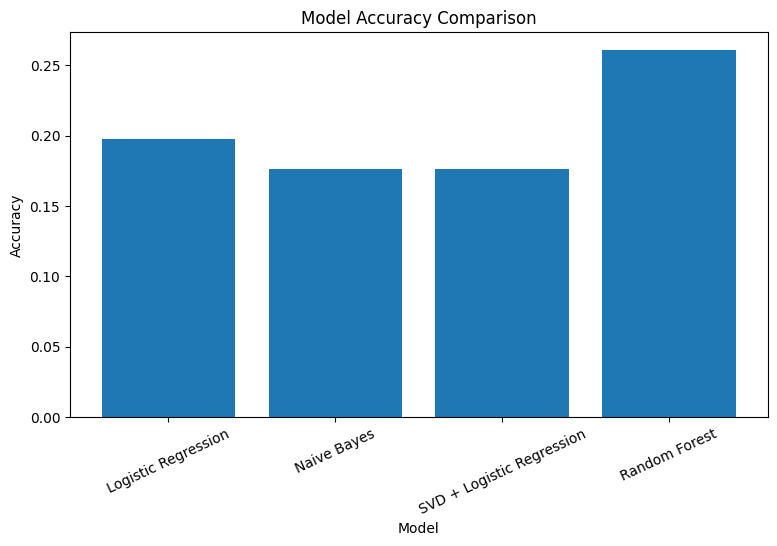

In [ ]:
plt.figure(figsize=(9,5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()

In [ ]:
best_model_row = model_results.sort_values(by="Accuracy", ascending=False).iloc[0]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Random Forest
Best Accuracy: 0.2605633802816901


In [ ]:
if best_model_name == "Logistic Regression":
    final_model = lr_model
elif best_model_name == "Naive Bayes":
    final_model = nb_model
elif best_model_name == "SVD + Logistic Regression":
    final_model = svd_lr_model
else:
    final_model = rf_model

In [ ]:
test_features = pd.get_dummies(test_df, drop_first=True)

test_features = test_features.reindex(columns=X.columns, fill_value=0)

final_predictions = final_model.predict(test_features)

final_predictions[:10]

array(['lively', 'extraverted', 'serious', 'lively', 'serious', 'lively',
       'extraverted', 'lively', 'responsible', 'lively'], dtype=object)

In [ ]:
submission = pd.DataFrame({
    "Person No": range(1, len(final_predictions) + 1),
    "Predicted Personality": final_predictions
})

submission.head()

,Person No,Predicted Personality
0,1,lively
1,2,extraverted
2,3,serious
3,4,lively
4,5,serious


In [ ]:
submission.to_csv("personality_predictions.csv", index=False)
